In [398]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [399]:
df =  pd.read_csv('college_student_placement_dataset.csv')
df

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No


In [400]:
df.duplicated().sum()

0

In [401]:
df.isnull().sum()


College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

In [402]:
df.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [403]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [404]:
df = df.drop(columns=['College_ID'],axis=1)
df

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,No,8,8,4,No
1,97,5.52,5.37,8,No,7,8,0,No
2,109,5.36,5.83,9,No,3,1,1,No
3,122,5.47,5.75,6,Yes,1,6,1,No
4,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...
9995,119,8.41,8.29,4,No,1,8,0,Yes
9996,70,9.25,9.34,7,No,0,7,2,No
9997,89,6.08,6.25,3,Yes,3,9,5,No
9998,107,8.77,8.92,3,No,7,5,1,No


In [405]:
df['Placement'] = df['Placement'].map({'Yes':1,'No':0})

<Axes: >

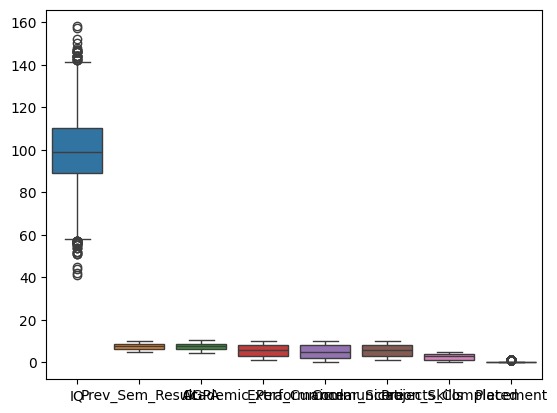

In [406]:
sns.boxplot(df)


In [407]:
X = df.drop(columns=['Placement'], axis=1)
Y = df['Placement']

In [408]:
num = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
num

['IQ',
 'Prev_Sem_Result',
 'CGPA',
 'Academic_Performance',
 'Extra_Curricular_Score',
 'Communication_Skills',
 'Projects_Completed']

In [409]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=42, test_size=0.2)

In [410]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(),  num),
    ('onehot', OneHotEncoder(drop='first'), ['Internship_Experience']),
], remainder='passthrough')
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('scaler', StandardScaler(),
                                 ['IQ', 'Prev_Sem_Result', 'CGPA',
                                  'Academic_Performance',
                                  'Extra_Curricular_Score',
                                  'Communication_Skills',
                                  'Projects_Completed']),
                                ('onehot', OneHotEncoder(drop='first'),
                                 ['Internship_Experience'])])

## Logistic Regression 90.35

In [411]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

Logistic = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(solver='liblinear', multi_class='ovr', max_iter=200))
])
Logistic

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['IQ', 'Prev_Sem_Result',
                                                   'CGPA',
                                                   'Academic_Performance',
                                                   'Extra_Curricular_Score',
                                                   'Communication_Skills',
                                                   'Projects_Completed']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Internship_Experience'])])),
                ('model',
                 LogisticRegression(max_iter=200, multi_class='ovr',
                                    solver='liblinear'))])

In [412]:
Logistic.fit(x_train, y_train)

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['IQ', 'Prev_Sem_Result',
                                                   'CGPA',
                                                   'Academic_Performance',
                                                   'Extra_Curricular_Score',
                                                   'Communication_Skills',
                                                   'Projects_Completed']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Internship_Experience'])])),
                ('model',
                 LogisticRegression(max_iter=200, multi_class='ovr',
                                    solver='liblinear'))])

In [413]:
Logistic.score(x_test, y_test)

0.9035

## Naive Bayes Classifier 91

In [414]:
from sklearn.naive_bayes import GaussianNB

NaiveBayes = Pipeline([
    ('preprocessing', preprocessor),
    ('model', GaussianNB(var_smoothing=1e-10))
])

In [415]:
NaiveBayes.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['IQ', 'Prev_Sem_Result',
                                                   'CGPA',
                                                   'Academic_Performance',
                                                   'Extra_Curricular_Score',
                                                   'Communication_Skills',
                                                   'Projects_Completed']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Internship_Experience'])])),
                ('model', GaussianNB(var_smoothing=1e-10))])

In [416]:
NaiveBayes.score(x_test, y_test)

0.91

## SVM Classifier 97.9

In [417]:
from sklearn.svm import SVC

svc = Pipeline([
    ('preprocessing', preprocessor),
    ('model', SVC(kernel='rbf' ,gamma='scale', C=1000))
])

In [418]:
svc.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['IQ', 'Prev_Sem_Result',
                                                   'CGPA',
                                                   'Academic_Performance',
                                                   'Extra_Curricular_Score',
                                                   'Communication_Skills',
                                                   'Projects_Completed']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Internship_Experience'])])),
                ('model', SVC(C=1000))])

In [419]:
svc.score(x_test, y_test)

0.979

## Descision Tree 96.3  

In [420]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

DecisionTree = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=3)) #giving 100 accuracy on max depth 4
])

In [421]:
DecisionTree.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['IQ', 'Prev_Sem_Result',
                                                   'CGPA',
                                                   'Academic_Performance',
                                                   'Extra_Curricular_Score',
                                                   'Communication_Skills',
                                                   'Projects_Completed']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Internship_Experience'])])),
                ('model', DecisionTreeClassifier(max_depth=3))])

In [422]:
DecisionTree.score(x_test, y_test)

0.963

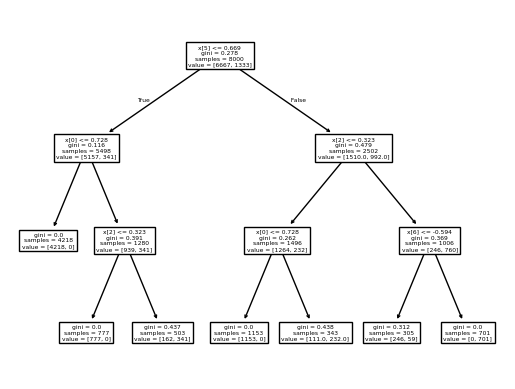

In [423]:
plot_tree(DecisionTree.named_steps['model'])
plt.show()

## KNN 95 

In [424]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=3, p=1))
])

In [425]:
knn.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['IQ', 'Prev_Sem_Result',
                                                   'CGPA',
                                                   'Academic_Performance',
                                                   'Extra_Curricular_Score',
                                                   'Communication_Skills',
                                                   'Projects_Completed']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Internship_Experience'])])),
                ('model', KNeighborsClassifier(n_neighbors=3, p=1))])

In [426]:
knn.score(x_test, y_test)

0.95

## XGBoost 99.05

In [427]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [428]:
from xgboost import XGBClassifier

xgb = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(booster='gbtree', max_depth=3, n_estimators=3))
])

In [429]:
xgb.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['IQ', 'Prev_Sem_Result',
                                                   'CGPA',
                                                   'Academic_Performance',
                                                   'Extra_Curricular_Score',
                                                   'Communication_Skills',
                                                   'Projects_Completed']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Internship_Experience'])])),
                ('model',
                 XGBClassifier(base_score=None, bo...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=3, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [430]:
xgb.score(x_test, y_test)

0.9905

## Random Forest 99.95

In [431]:
from sklearn.ensemble import RandomForestClassifier

RandomForest = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(n_estimators=7))
])

In [432]:
RandomForest.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['IQ', 'Prev_Sem_Result',
                                                   'CGPA',
                                                   'Academic_Performance',
                                                   'Extra_Curricular_Score',
                                                   'Communication_Skills',
                                                   'Projects_Completed']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Internship_Experience'])])),
                ('model', RandomForestClassifier(n_estimators=7))])

In [433]:
RandomForest.score(x_test, y_test)

0.9995